## Analysis of the Hidden-Layer Representations


### This notebook loads the pretrained *.pth* files and plots Figure 4


In [1]:
import json
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from bnbp5.bnn_intralayer import *
from bnbp5.trainnospikemne_intralayer_timeind_sliding_128 import Trainer
from bnbp5.mnist_spiketrain_sliding import *
from os.path import exists

from zanj import ZANJ

from torchvision import datasets, transforms
from torch import nn
import torch

from sklearn.metrics import silhouette_score
from scipy.stats import entropy

from matplotlib.lines import Line2D

import seaborn as sns

torch.set_default_dtype(torch.float32)

/home/mccruz/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
files = [
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca115_Iapp0.30000000000000004.pth",#_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca115_Iapp0.5_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca115_Iapp0.7000000000000001_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca125_Iapp0.30000000000000004_cont3.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca125_Iapp0.5_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca125_Iapp0.7000000000000001_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca75_Iapp0.30000000000000004_cont3.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca75_Iapp0.5.pth",#_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca75_Iapp0.7000000000000001_cont3.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca95_Iapp0.30000000000000004_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca95_Iapp0.5_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca95_Iapp0.7000000000000001_cont3.pth"]

In [3]:
files2 = [
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gca0.0_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gca0.06_cont2.pth",    
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gca0.24_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gca0.0_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gca0.06_cont3.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gca0.24_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gca0.0_cont1.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gca0.06_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gca0.24_cont1.pth",]

In [4]:
files3 = [
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk0.0_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk17.5.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk70.0_cont3.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk0.0.pth", #_cont1
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk17.5_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_cont2.pth",    
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk70.0_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gk0.0_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gk17.5_cont3.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_cont2.pth",
"/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gk70.0_cont3.pth",]

In [17]:
# Computing neuron_selectivity

def compute_neuron_selectivity(H, labels):
    """
    H: (samples, neurons)
    labels: (samples,)

    Returns mean neuron selectivity index (variance-ratio / eta-squared style):
    fraction of each neuron's total response variance explained by class identity.
    0 = class has no effect on this neuron's voltage, 1 = fully class-determined.
    """
    classes = np.unique(labels)
    # neuron x class tuning curve
    tuning = np.zeros((H.shape[1], len(classes)))
    for i, c in enumerate(classes):
        tuning[:, i] = H[labels == c].mean(axis=0)

    # Between-class variance (how spread out the class means are) relative to
    # each neuron's total variance across all samples (signal vs. noise), not
    # relative to the class means' own spread. This is why it scales with real
    # mV differences instead of collapsing to a noise-shape constant.
    grand_mean = tuning.mean(axis=1, keepdims=True)
    between_var = ((tuning - grand_mean) ** 2).mean(axis=1)
    total_var = H.var(axis=0) + 1e-8
    SI = between_var / total_var

    return np.mean(SI)

In [22]:
def training_metrics4(
    files,
    param_name="ECa",
    param_index=None,
    param_slice=None,
    param_type=float,
    default_value=None,
):
    """
    Parameters
    ----------
    param_name : {"ECa", "gCa", "gk"}
        Parameter to extract from filename.
    """

    defaults = {
        "ECa": {
            "index": 6,
            "slice": slice(3, None),   # ECa120 -> 120
            "type": int,
            "default": None,
        },
        "gCa": {
            "index": 8,
            "slice": slice(3, None),   # gCa0.12 -> 0.12
            "type": float,
            "default": 0.12,
        },
        "gk": {
            "index": 8,
            "slice": slice(2, None),   # gk35 -> 35
            "type": float,
            "default": 35,
        },
    }

    cfg = defaults[param_name]

    if param_index is None:
        param_index = cfg["index"]
    if param_slice is None:
        param_slice = cfg["slice"]
    if param_type is float:
        param_type = cfg["type"]
    if default_value is None:
        default_value = cfg["default"]

    all_metrics = {}

    for f in files:

        print(f)
        state = torch.load(f, map_location="cpu", weights_only=False)

        # Hidden activity
        V_train = torch.cat(
            [
                torch.cat(sample_layers, dim=1)
                for sample_layers in state["hidden_Vs_train"]
            ],
            dim=0,
        )

        labels_train = torch.stack([
            torch.cat(sample_layers, dim=0)
            for sample_layers in state["labels_V_train"]
        ])

        silhouette_epochs = []
        selectivity_epochs = []

        for epch in range(10):

            try:
                V = V_train[epch]
                labels = labels_train[epch]
            except IndexError:
                V = V_train[-1]
                labels = labels_train[-1]

            H = V.mean(dim=1)

            H_np = H.detach().cpu().numpy()
            labels_np = labels.detach().cpu().numpy()

            valid = np.isfinite(H_np).all(axis=1)
            H_np = H_np[valid]
            labels_np = labels_np[valid]

            unique, counts = np.unique(labels_np, return_counts=True)

            if len(unique) < 2 or np.min(counts) < 2:
                silhouette_epochs.append(np.nan)
            else:
                silhouette_epochs.append(
                    silhouette_score(H_np, labels_np)
                )

            selectivity_epochs.append(
                compute_neuron_selectivity(H_np, labels_np)
            )


        # Parsing filename
        parts = str(f).split("_")
        
        #print(parts)

        try:
            param = param_type(parts[param_index][param_slice])
            #print(param)
            IApp = float(parts[7][4:7])
            key = (param, IApp)
        except Exception:
            if default_value is None:
                key = str(f)
            else:
                IApp = float(parts[7][4:7])
                key = (default_value, IApp)
                
        if f == "/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk17.5.pth":
            param = 17.5
            key = (param, IApp)
            
        elif f == '/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk0.0.pth':
            param = 0.0
            key = (param, IApp)
        

        print(key)

        try:
            all_metrics[key] = {
                "accuracy": (
                    torch.tensor(state["accuracies_epochs"])
                    .squeeze(0)
                    .mean(axis=1)
                    .cpu()
                    .numpy()
                ),
                "training accuracy": state["training_accuracies_epochs"],
                "silhouette": silhouette_epochs,
                "selectivity": selectivity_epochs,
            }
        except IndexError:
            pass

    return all_metrics

In [5]:
def plot_representations(all_metrics, axeslabels = ["IApp","ECa"],titles="Representation learning under different biophysical parameters"):
    parsed_keys = [k for k in all_metrics if isinstance(k, tuple)]
    unparsed_keys = [k for k in all_metrics if not isinstance(k, tuple)]
    if unparsed_keys:
        print(f"Skipping {len(unparsed_keys)} run(s) with unparsed ECa/IApp: {unparsed_keys}")

    ecas = sorted(set(k[0] for k in parsed_keys))
    iapps = sorted(set(k[1] for k in parsed_keys))

    eca_palette = np.array(sns.color_palette("colorblind", n_colors=10))
    eca_palette = eca_palette[[0, 1, 2, 4, 9, 3, 5, 6, 7, 8]]
    eca_color = {eca: eca_palette[i] for i, eca in enumerate(ecas)}

    crest_cmap = sns.color_palette("viridis", as_cmap=True)#"cividis"

    style_options = [(0, (1, 1)), (0, (5, 2)), "solid", (0, (3, 1, 1, 1))]
    linestyles = {v: style_options[i % len(style_options)] for i, v in enumerate(iapps)}

    metrics = [("training accuracy", "Training Accuracy"), ("accuracy", "Testing Accuracy"), ("silhouette", "Silhouette Score"), ("selectivity", "Neuron Selectivity")]

    fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), gridspec_kw={"height_ratios": [1.3, 1]})
    fig.subplots_adjust(left=0.045, right=0.97, top=0.90, bottom=0.06, wspace=0.45, hspace=0.4)
    fig.suptitle(titles, fontsize=20, y=1.05, fontproperties=prop_bold3)

    # Row 1: trajectories, color=ECa, linestyle=IApp
    for col, (key, label) in enumerate(metrics):
        ax = axes[0, col]
        for eca, iapp in parsed_keys:
            vals = np.asarray(all_metrics[(eca, iapp)][key], dtype=float)
            ax.plot(
                range(len(vals)), vals,
                color=eca_color[eca], linestyle=linestyles[iapp],
                marker="o", markersize=3.5, linewidth=1.6, alpha=0.9,
            )
        ax.set_title(label, fontproperties=prop_bold)
        ax.set_xlabel("Epoch", fontproperties=prop_bold)
        ax.set_ylabel(label, fontproperties=prop_bold)
        for tick in ax.get_xticklabels():
            tick.set_fontproperties(prop)

        for tick in ax.get_yticklabels():
            tick.set_fontproperties(prop)
        #ax.grid(alpha=0.3)

    legend_lines = [Line2D([0], [0], color="black", linestyle=linestyles[v], lw=1.8) for v in iapps]
    fig.legend(legend_lines, [f"{axeslabels[0]}={v}" for v in iapps], loc="upper right",
               bbox_to_anchor=(0.97, 1.03), ncol=len(iapps), frameon=False, fontsize=9, prop=prop)

    eca_legend_lines = [Line2D([0], [0], color=eca_color[eca], lw=2.5) for eca in ecas]
    fig.legend(eca_legend_lines, [f"{axeslabels[1]}={eca}" for eca in ecas], loc="upper right",
               bbox_to_anchor=(0.97, 1.0), ncol=len(ecas), frameon=False, fontsize=9, prop=prop)

    # Row 2: heatmap of converged value per (ECa, IApp) 
    for col, (key, label) in enumerate(metrics):
        ax = axes[1, col]
        grid = np.full((len(ecas), len(iapps)), np.nan)
        for eca, iapp in parsed_keys:
            i, j = ecas.index(eca), iapps.index(iapp)
            vals = np.asarray(all_metrics[(eca, iapp)][key], dtype=float)
            grid[i, j] = np.nanmean(vals[-2:]) 

        im = ax.imshow(grid, aspect="auto", cmap=crest_cmap)
        ax.set_xticks(range(len(iapps)), [str(v) for v in iapps], fontproperties=prop)
        ax.set_yticks(range(len(ecas)), [str(v) for v in ecas], fontproperties=prop)
        ax.set_xlabel(f"{axeslabels[0]}",fontproperties=prop_bold)
        ax.set_ylabel(f"{axeslabels[1]}",fontproperties=prop_bold)
        ax.set_title(f"Converged {label}", fontproperties=prop_bold) #(last 2 epochs, mean)

        vmin, vmax = np.nanmin(grid), np.nanmax(grid)
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        for i in range(len(ecas)):
            for j in range(len(iapps)):
                val = grid[i, j]
                if np.isnan(val):
                    continue
                fmt = f"{val:.4f}" if abs(val) < 0.01 else (f"{val:.2f}" if abs(val) < 10 else f"{val:.0f}")
                # text color from the actual sampled cell color's luminance, so it
                # stays correct regardless of which direction a colormap runs
                r, g, b, _ = crest_cmap(norm(val))
                luminance = 0.299 * r + 0.587 * g + 0.114 * b
                txt_color = "white" if luminance < 0.5 else "black"
                ax.text(j, i, fmt, ha="center", va="center", color=txt_color, fontproperties=prop2)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        for tick in cbar.ax.get_yticklabels():
            tick.set_fontproperties(prop)


    plt.savefig("representation_learning_biophysical.png", dpi=300, bbox_inches="tight")
    plt.show()



In [7]:
from matplotlib import font_manager as fm

font_path_bold = "/home/mccruz/26063"#font_acumin"  # Replace with the path to your font file
font_path = "/home/mccruz/font_acumin"
prop = fm.FontProperties(fname=font_path, size = 14)
prop2 = fm.FontProperties(fname=font_path, size = 16)
prop_bold = fm.FontProperties(
    fname=font_path_bold,
    size=18,
    weight='bold'
)

prop_bold2 = fm.FontProperties(
    fname=font_path_bold,
    size=16,
    weight='bold'
)

prop_bold3 = fm.FontProperties(
    fname=font_path_bold,
    size=40,
    weight='bold'
)


In [25]:
 all_metrics = training_metrics4(files,"ECa")

/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca115_Iapp0.30000000000000004.pth
(115, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca115_Iapp0.5_cont2.pth
(115, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca115_Iapp0.7000000000000001_cont1.pth
(115, 0.7)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca125_Iapp0.30000000000000004_cont3.pth
(125, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca125_Iapp0.5_cont1.pth
(125, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca125_Iapp0.7000000000000001_cont1.pth
(125, 0.7)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_cont2.pth
(55, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_cont2.pth
(55, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_cont2.pth
(55, 0.7)
/nfs/turbo

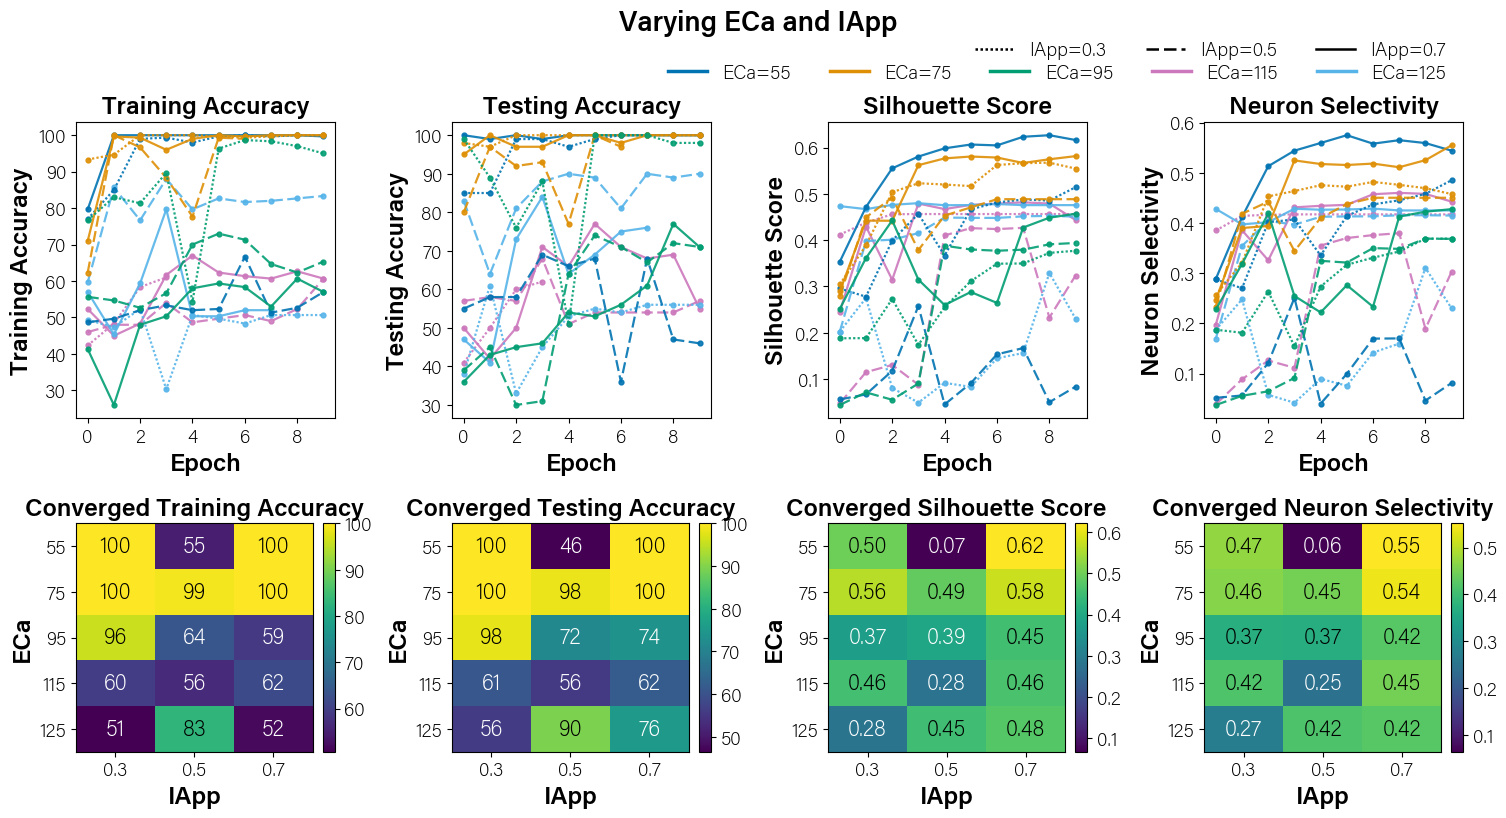

In [79]:
plot_representations(all_metrics,titles="Varying ECa and IApp")

In [80]:
 all_metrics2 = training_metrics4(files2,"gCa")

/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gca0.0_cont2.pth
(0.0, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gca0.06_cont2.pth
(0.06, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_cont2.pth
(0.12, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gca0.24_cont2.pth
(0.24, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gca0.0_cont2.pth
(0.0, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gca0.06_cont3.pth
(0.06, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_cont2.pth
(0.12, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gca0.24_cont1.pth
(0.24, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000

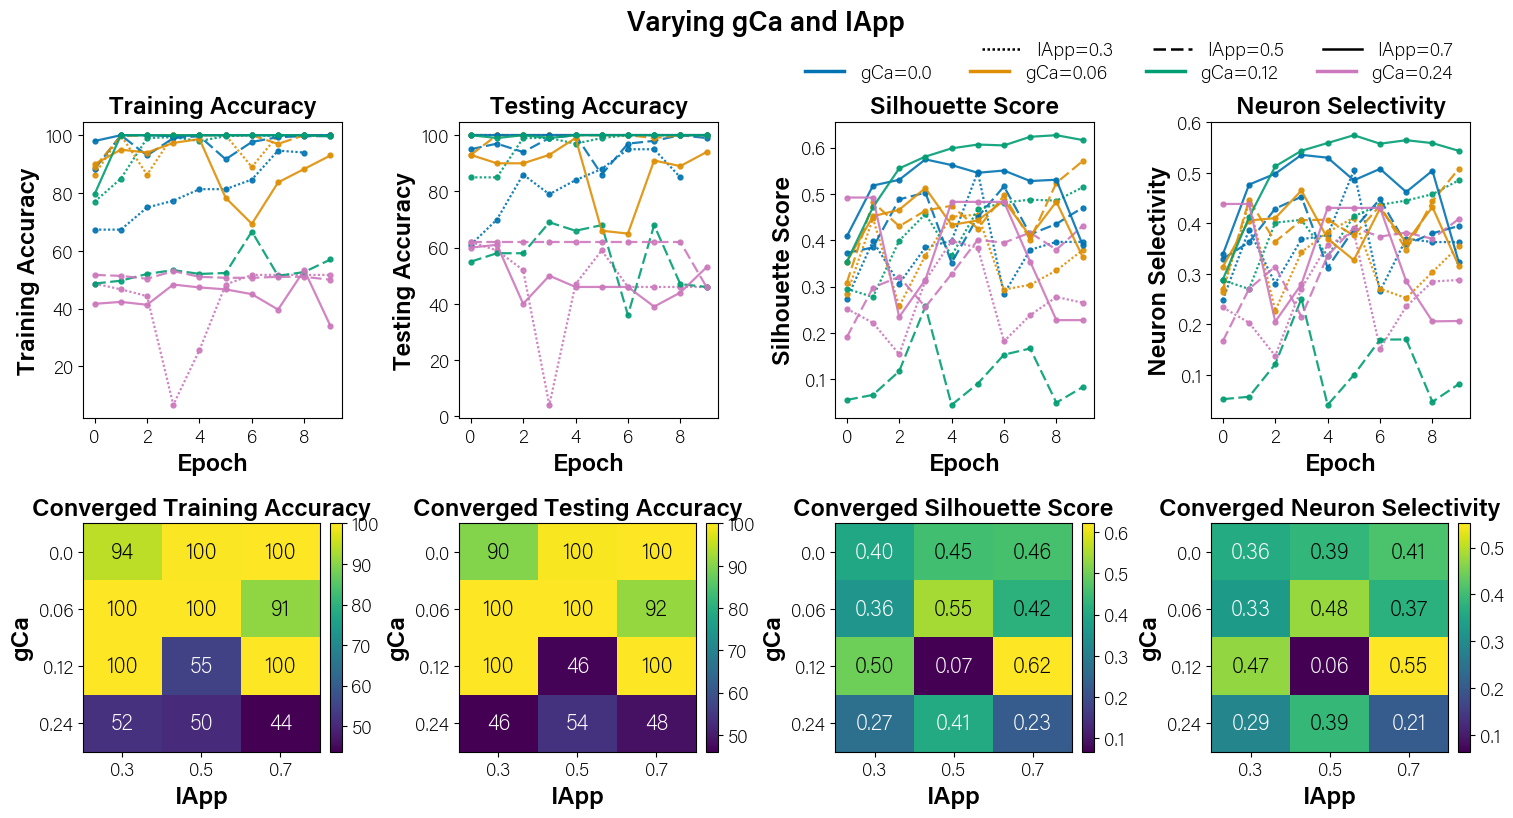

In [81]:
plot_representations(all_metrics2, ["IApp", "gCa"],titles="Varying gCa and IApp")

In [82]:
 all_metrics3 = training_metrics4(files3, "gk")

/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk0.0_cont2.pth
(0.0, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk17.5.pth
(17.5, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_cont2.pth
(35, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.30000000000000004_gk70.0_cont3.pth
(70.0, 0.3)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk0.0.pth
(0.0, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk17.5_cont2.pth
(17.5, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_cont2.pth
(35, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.5_gk70.0_cont2.pth
(70.0, 0.5)
/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gk0.0_cont2.

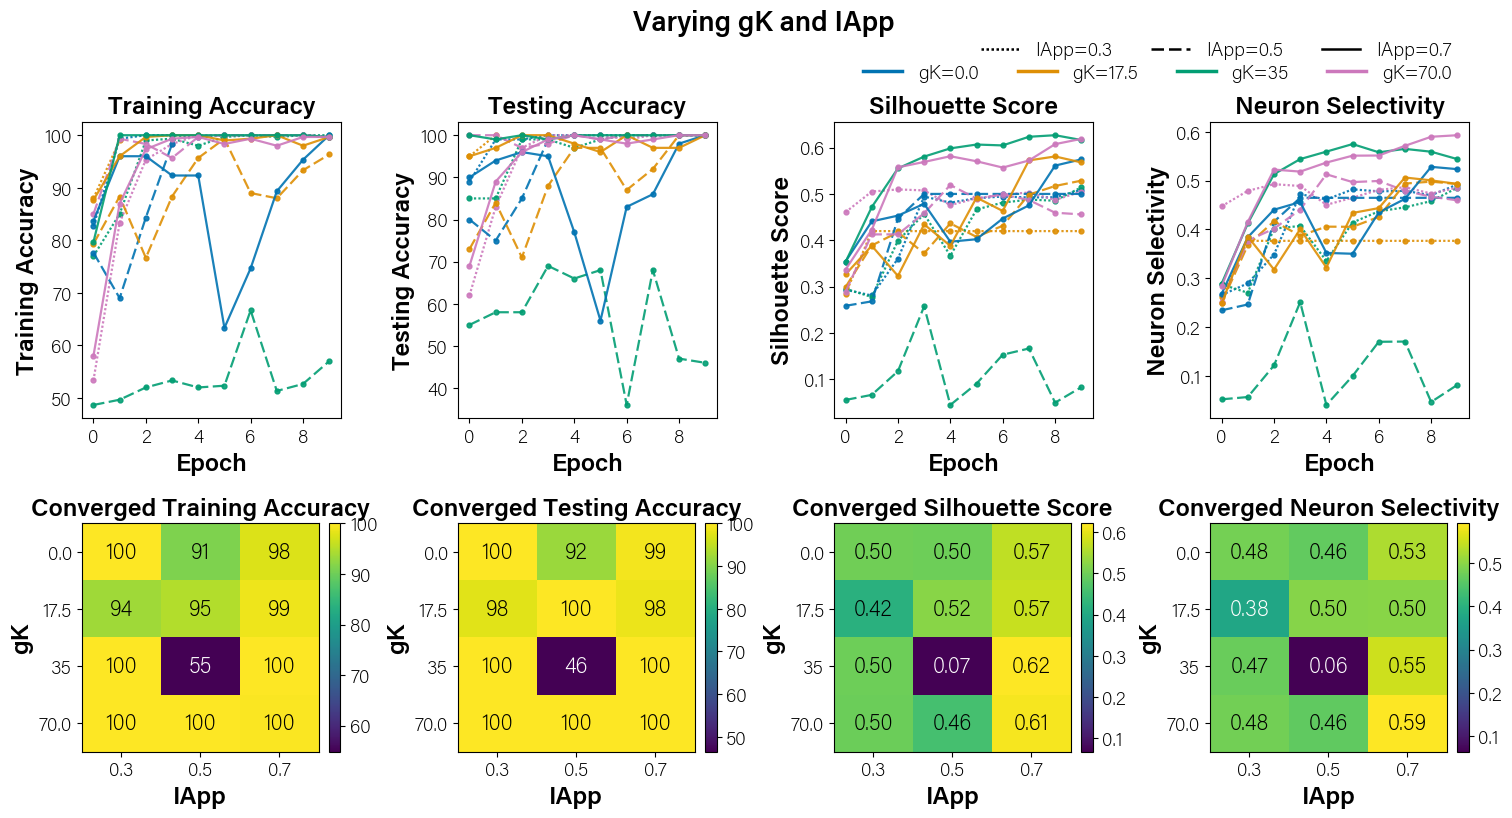

In [83]:
plot_representations(all_metrics3, ["IApp", "gK"],titles="Varying gK and IApp")

## tSNE

In [8]:
state = torch.load("/nfs/turbo/lsa-forger/mccruz/BNN_IBN_Anesthesia_Sub007_hidden_Vs_Eca55_Iapp0.7000000000000001_gca0.0_cont1.pth")    


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
For more detailed error information, run with CUDA_LOG_FILE=stderr


In [73]:
V_train = torch.cat(
    [
        torch.cat(sample_layers, dim=1)
        for sample_layers in state['hidden_Vs_train']
    ],
    dim=0
)

V_test = torch.cat(
    [
        torch.cat(sample_layers, dim=1)
        for sample_layers in state['hidden_Vs_test']
    ],
    dim=0
)


labels_train = torch.stack([
    torch.cat([t.cpu() for t in sample_layers], dim=0)
    for sample_layers in state['labels_V_train']
])

labels_test = torch.stack([
    torch.cat([t.cpu() for t in sample_layers], dim=0)
    for sample_layers in state['labels_V_test']
])

guess_train = torch.stack([
    torch.cat([t.cpu() for t in sample_layers], dim=0)
    for sample_layers in state['guess_V_train']
])

guess_test = torch.stack([
    torch.cat([t.cpu() for t in sample_layers], dim=0)
    for sample_layers in state['guess_V_test']
])


Epoch: 0

Epoch: 1

Epoch: 2

Epoch: 3

Epoch: 4

Epoch: 5

Epoch: 6

Epoch: 7

Epoch: 8

Epoch: 9


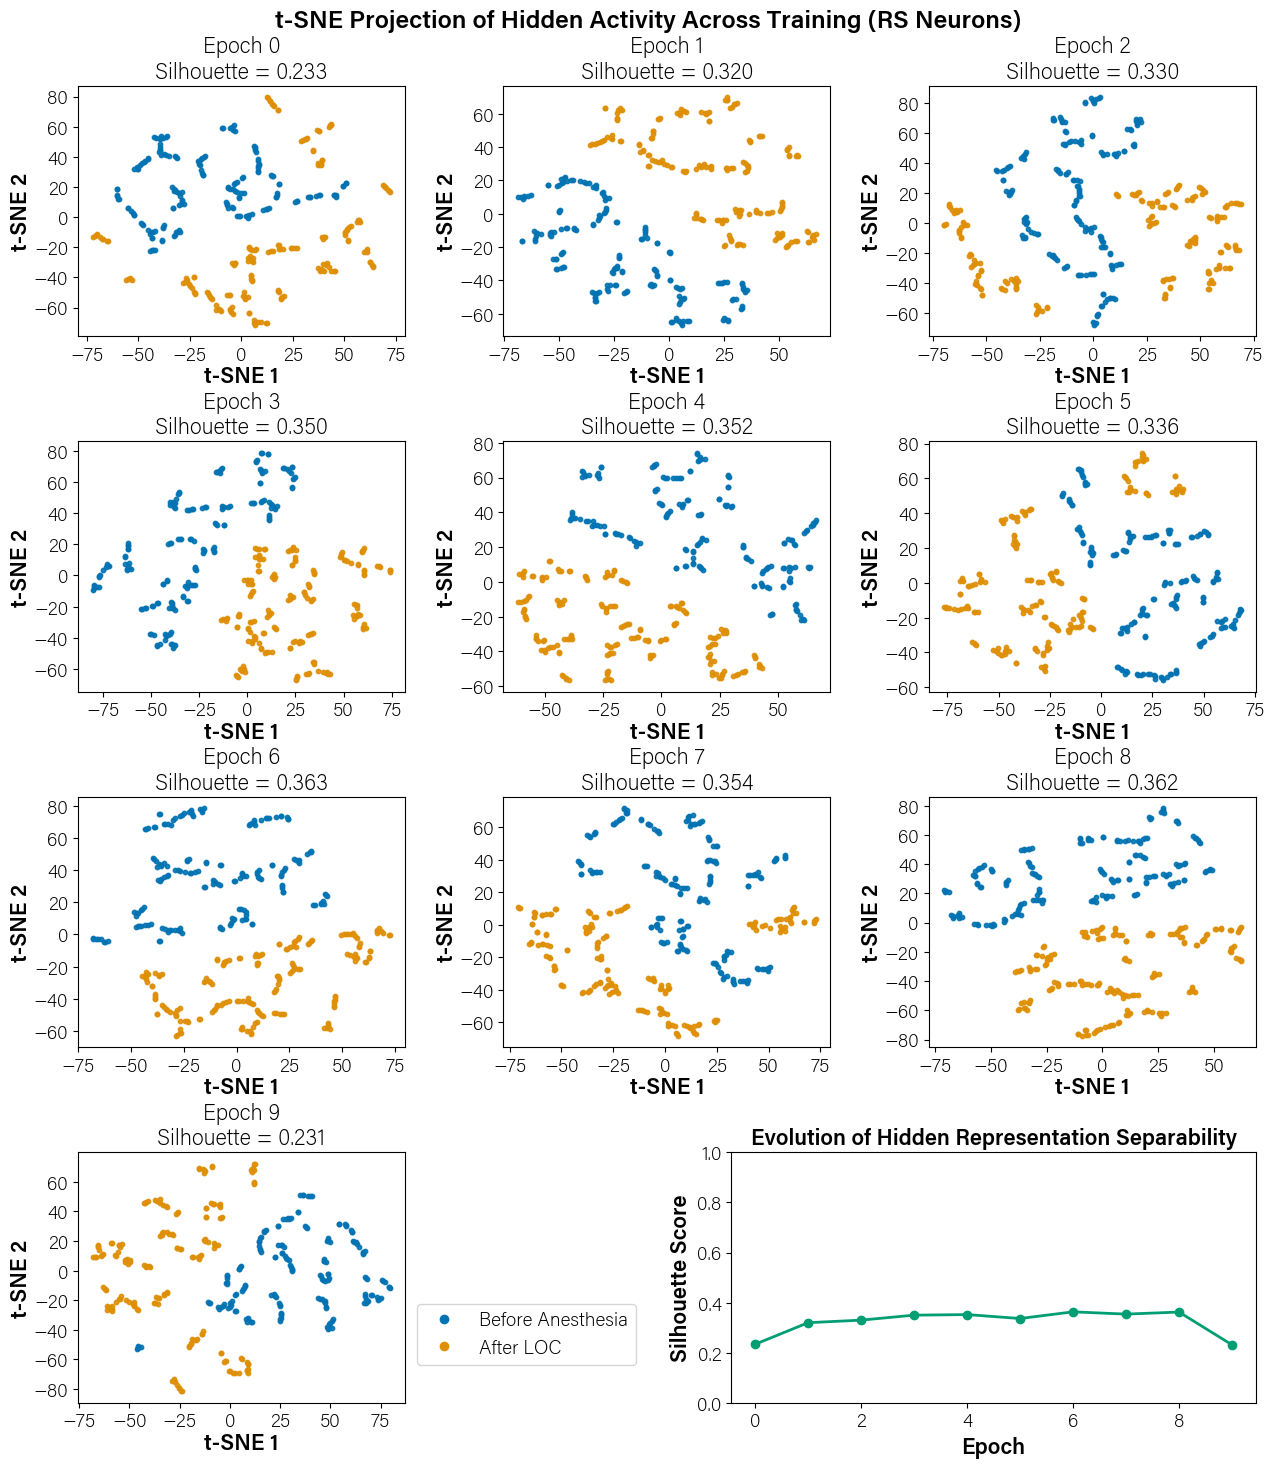

In [66]:
## t-SNE + Silhouette Score

from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

n_samples = 350
n_timepoints = 2201
n_channels = 100

silhouette_scores = []

colors = ["#0173B2", "#DE8F05","#029E73"]

fig = plt.figure(figsize=(8*1.9, 9*1.9))

gs = fig.add_gridspec(
    4, 3,
    hspace=0.42,
    wspace=0.3
)

axes = []

for i in range(10):
    row = i // 3
    col = i % 3
    axes.append(fig.add_subplot(gs[row, col]))

# Silhouette plot
ax_silhouette = fig.add_subplot(gs[3, 1:3])


# -----------------------------------
# Concatenate test + train for plotting
# -----------------------------------

V_all = torch.cat([V_test, V_train], dim=1)
labels_all = torch.cat([labels_test, labels_train], dim=1)


# -----------------------------------
# t-SNE for all 10 epochs
# -----------------------------------

for epch in range(10):

    ax = axes[epch]

    X_time = V_all[epch].cpu().detach().numpy()
    y = labels_all[epch].cpu().detach().numpy()

    print("\nEpoch:", epch)

    # Flatten
    X = X_time.reshape(
        n_samples,
        n_timepoints * n_channels
    )

    
    valid = np.isfinite(X).all(axis=1)

    X = X[valid]
    y = y[valid]

    # Silhouette score
    score = silhouette_score(
        X,
        y,
        metric="euclidean"
    )

    silhouette_scores.append(score)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=3,
        max_iter=1000,
        random_state=42
    )

    X_embedded = tsne.fit_transform(X)

    # Plotting
    for class_idx in np.unique(y):
        idx = y == class_idx

        ax.scatter(
            X_embedded[idx, 0],
            X_embedded[idx, 1],
            color=colors[int(class_idx) % len(colors)],
            s=10,
            label=str(class_idx),
            alpha=0.9
        )

        ax.set_title(
        f"Epoch {epch}\nSilhouette = {score:.3f}",
        fontproperties=prop2
    )

    ax.set_xlabel(
        "t-SNE 1",
        fontproperties=prop_bold2,
        labelpad=1
    )

    ax.set_ylabel(
        "t-SNE 2",
        fontproperties=prop_bold2,
        labelpad=1
    )

    for tick in ax.get_xticklabels():
        tick.set_fontproperties(prop)

    for tick in ax.get_yticklabels():
        tick.set_fontproperties(prop)


ax = ax_silhouette

pos = ax_silhouette.get_position()
ax_silhouette.set_position([
    pos.x0 + 0.15,   
    pos.y0,
    pos.width - 0.15,
    pos.height
])

ax.plot(
    range(10),
    silhouette_scores,
    marker="o",
    linewidth=2,
    color=colors[2],
    markerfacecolor=colors[2],
    markeredgecolor=colors[2]
)

ax.set_xlabel(
    "Epoch",
    fontproperties=prop_bold2
)

ax.set_ylabel(
    "Silhouette Score",
    fontproperties=prop_bold2
)

ax.set_title(
    "Evolution of Hidden Representation Separability",
    fontproperties=prop_bold2
)

for tick in ax.get_xticklabels():
    tick.set_fontproperties(prop)

for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)

ax.set_ylim(0, 1)  
#ax.grid(True, alpha=0.3)

# Class Legends
unique_classes = np.unique(
    labels_all[0].cpu().numpy()
)

palette = colors[:len(unique_classes)]

legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=7,
        markerfacecolor=palette[i],
        markeredgecolor="none"
    )
    for i in range(len(unique_classes))
]

legend = fig.legend(
    legend_handles,
    ["Before Anesthesia", "After LOC"],
    loc="center",
    bbox_to_anchor=(0.42, 0.15),
    prop=prop,
    frameon=True
)

legend.get_title().set_fontproperties(prop2)

fig.suptitle(
    "t-SNE Projection of Hidden Activity Across Training (RS Neurons)",
    fontproperties=prop_bold,
    y=0.925,       # closer to the first row
)

plt.show()


Epoch: 0


/home/mccruz/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mccruz/.local/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")



Epoch: 1


/home/mccruz/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mccruz/.local/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")



Epoch: 2


...

/home/mccruz/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mccruz/.local/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")



Epoch: 8


/home/mccruz/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mccruz/.local/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")



Epoch: 9


/home/mccruz/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mccruz/.local/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


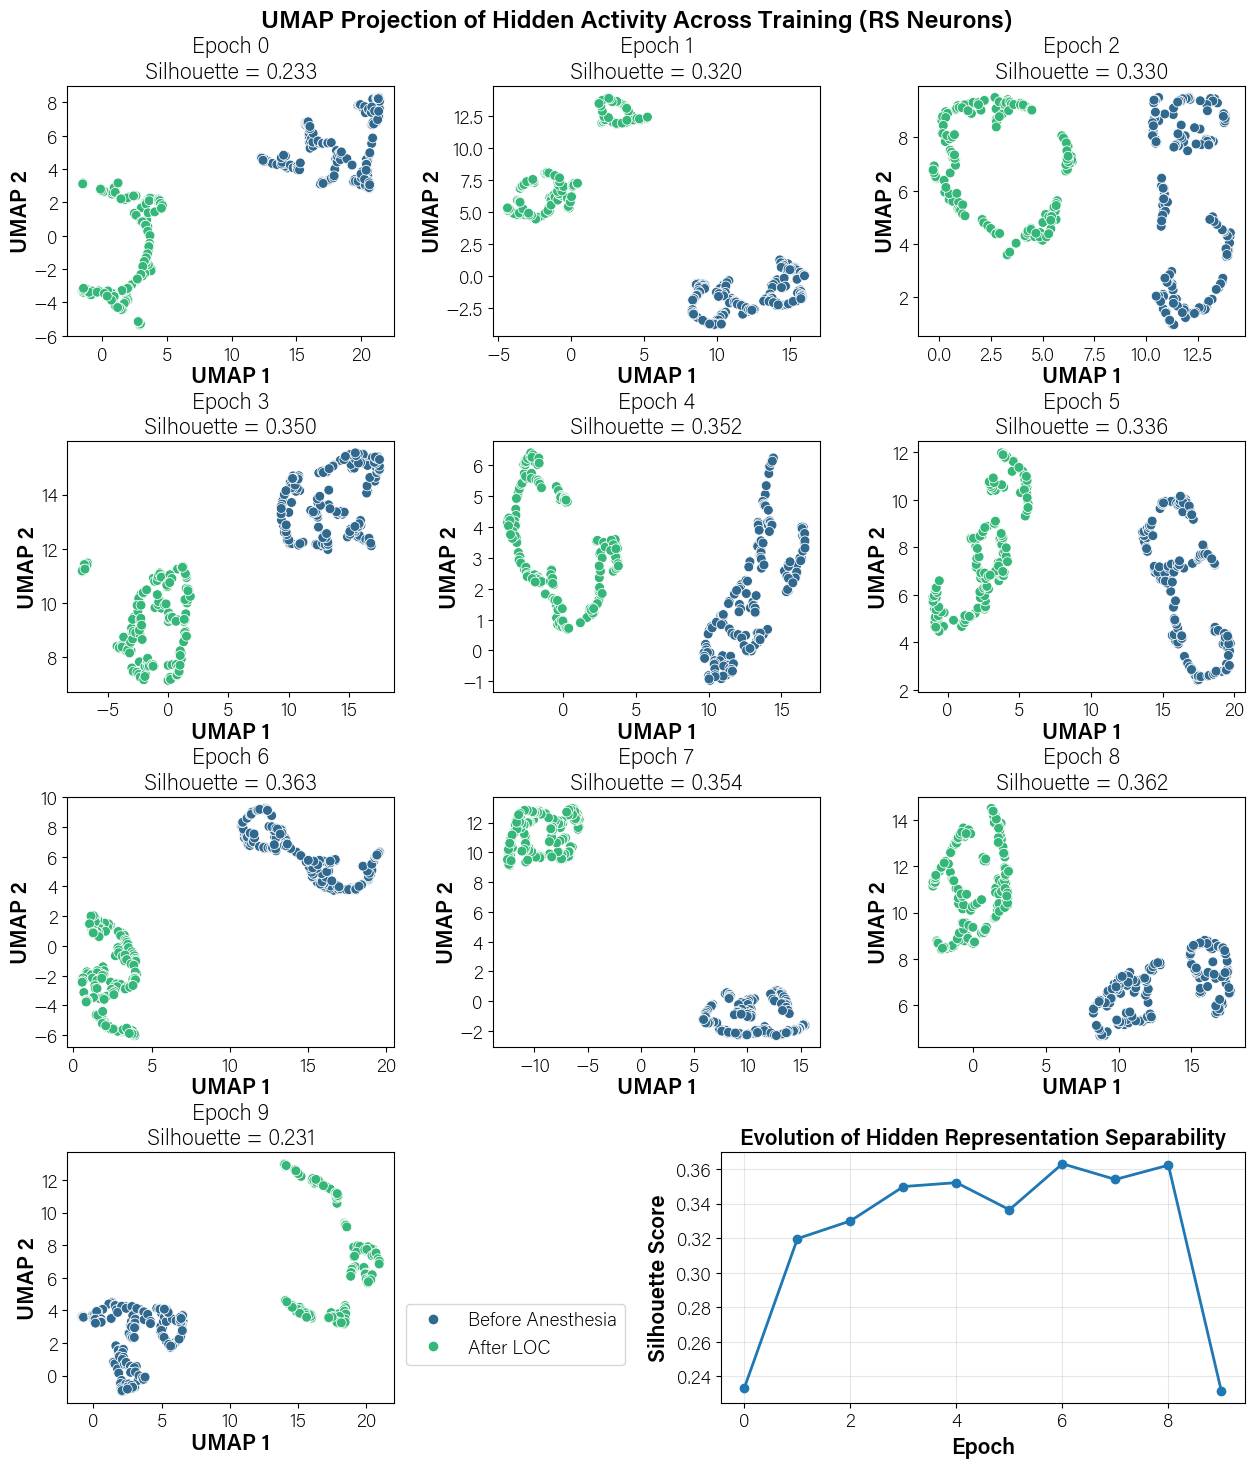

In [76]:
## UMAP + Silhouette Score
## 4x3 figure: 10 UMAP plots + silhouette plot spanning last 2 columns

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from sklearn.metrics import silhouette_score

n_samples = 350
n_timepoints = 2201
n_channels = 100

silhouette_scores = []

# -----------------------------------
# Create 4 x 3 figure
# -----------------------------------

fig = plt.figure(figsize=(8*1.9, 9*1.9))

gs = fig.add_gridspec(
    4, 3,
    hspace=0.42,
    wspace=0.3
)

# 10 UMAP axes
axes = []

for i in range(10):
    row = i // 3
    col = i % 3
    axes.append(fig.add_subplot(gs[row, col]))

# Silhouette plot spans last two columns
ax_silhouette = fig.add_subplot(gs[3, 1:3])


# -----------------------------------
# Concatenate test + train
# -----------------------------------

V_all = torch.cat([V_test, V_train], dim=1)
labels_all = torch.cat([labels_test, labels_train], dim=1)


# -----------------------------------
# UMAP for all 10 epochs
# -----------------------------------

for epch in range(10):

    ax = axes[epch]

    X_time = V_all[epch].cpu().detach().numpy()
    y = labels_all[epch].cpu().detach().numpy()

    print("\nEpoch:", epch)

    # -----------------------------------
    # Flatten
    # -----------------------------------

    X = X_time.reshape(
        n_samples,
        n_timepoints * n_channels
    )

    # -----------------------------------
    # Remove NaN/Inf samples
    # -----------------------------------

    valid = np.isfinite(X).all(axis=1)

    X = X[valid]
    y = y[valid]

    # -----------------------------------
    # Silhouette score
    # -----------------------------------

    score = silhouette_score(
        X,
        y,
        metric="euclidean"
    )

    silhouette_scores.append(score)

    # -----------------------------------
    # UMAP
    # -----------------------------------

    reducer = UMAP(
        n_components=2,
        n_neighbors=10,
        min_dist=0.1,
        random_state=42
    )

    X_embedded = reducer.fit_transform(X)

    # -----------------------------------
    # Plot
    # -----------------------------------

    sns.scatterplot(
        x=X_embedded[:, 0],
        y=X_embedded[:, 1],
        hue=y,
        palette="viridis",
        s=50,
        ax=ax,
        legend=False
    )

    ax.set_title(
        f"Epoch {epch}\nSilhouette = {score:.3f}",
        fontproperties=prop2
    )

    ax.set_xlabel(
        "UMAP 1",
        fontproperties=prop_bold2,
        labelpad=1
    )

    ax.set_ylabel(
        "UMAP 2",
        fontproperties=prop_bold2,
        labelpad=1
    )

    for tick in ax.get_xticklabels():
        tick.set_fontproperties(prop)

    for tick in ax.get_yticklabels():
        tick.set_fontproperties(prop)


# -----------------------------------
# Silhouette evolution
# -----------------------------------

ax = ax_silhouette
pos = ax_silhouette.get_position()
ax_silhouette.set_position([
    pos.x0 + 0.15,   # move right
    pos.y0,
    pos.width - 0.15,
    pos.height
])

ax.plot(
    range(10),
    silhouette_scores,
    marker="o",
    linewidth=2
)

ax.set_xlabel(
    "Epoch",
    fontproperties=prop_bold2
)

ax.set_ylabel(
    "Silhouette Score",
    fontproperties=prop_bold2
)

ax.set_title(
    "Evolution of Hidden Representation Separability",
    fontproperties=prop_bold2
)

for tick in ax.get_xticklabels():
    tick.set_fontproperties(prop)

for tick in ax.get_yticklabels():
    tick.set_fontproperties(prop)

ax.grid(True, alpha=0.3)


# -----------------------------------
# Shared class legend
# -----------------------------------

unique_classes = np.unique(
    labels_all[0].cpu().numpy()
)

palette = sns.color_palette(
    "viridis",
    n_colors=len(unique_classes)
)

legend_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=7,
        markerfacecolor=palette[i],
        markeredgecolor="none"
    )
    for i in range(len(unique_classes))
]

# Put legend in the empty bottom-left subplot area
legend = fig.legend(
    legend_handles,
    ["Before Anesthesia", "After LOC"],
    loc="center",
    bbox_to_anchor=(0.42, 0.15),
    prop=prop,
    frameon=True
)

legend.get_title().set_fontproperties(prop2)


# -----------------------------------
# Overall title
# -----------------------------------

fig.suptitle(
    "UMAP Projection of Hidden Activity Across Training (RS Neurons)",
    fontproperties=prop_bold,
    y=0.925,       # closer to the first row
)

plt.show()